In [1]:
!pip install faiss-cpu
!pip install PyPDF2 python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 19.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import pickle
import faiss
from sentence_transformers import SentenceTransformer
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
from tqdm import tqdm
import warnings
from typing import List, Dict
import os

warnings.filterwarnings('ignore')

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load dataset
df = pd.read_csv("/content/AI_Resume_Matcher_Dataset.csv")
print(f"Loaded {len(df)} resumes")
print(f"Columns: {df.columns.tolist()}")
print(f"Sample data:\n{df.head(2)}")
print(f"\nDataset info:")
print(df.info())

Loaded 2000 resumes
Columns: ['Name', 'Experience_Years', 'Skills', 'Education', 'Applied_Job_Role']
Sample data:
          Name  Experience_Years             Skills Education Applied_Job_Role
0  Candidate_0                 1   Node.js, MongoDB       BCA   Data Scientist
1  Candidate_1                 7  JavaScript, React     B.Com  Product Manager

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              2000 non-null   object
 1   Experience_Years  2000 non-null   int64 
 2   Skills            2000 non-null   object
 3   Education         2000 non-null   object
 4   Applied_Job_Role  2000 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB
None


In [ ]:
# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

TEXT EXTRACTION FUNCTIONS (CRITICAL FOR HANDLING DIFFERENT FILE TYPES)

In [5]:
# Text extraction from different formats
def extract_text_from_file(file_path):
  if file_path.endswith(".pdf"):
    with open(file_path, "rb") as file:
      reader = PyPDF2.PdfReader(file)  #read pages and text
      text = ""
      for page in reader.pages:
        text += page.extract_text()
    return text
  elif file_path.endswith(".docx"):
    doc = docx.Document(file_path)
    text = "\n".join([paragraph.text for paragraph in doc.paragraphs])
    return text
  else:
      with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        return file.read()

TEXT PREPROCESSING FUNCTIONS

In [6]:
# Preprocess and create resume text from structured data
def create_resume_text(row):
    """Create comprehensive resume text from structured data"""
    resume_parts = []

    # Name
    if pd.notna(row.get('Name', '')):
        resume_parts.append(f"Name: {row['Name']}")

    # Experience
    if pd.notna(row.get('Experience_Years', '')):
        resume_parts.append(f"Experience: {row['Experience_Years']} years")

    # Skills (detailed)
    if pd.notna(row.get('Skills', '')):
        skills = row['Skills']
        if isinstance(skills, str):
            skill_list = [s.strip() for s in skills.split(',')]
            resume_parts.append(f"Skills: {', '.join(skill_list)}")

    # Education
    if pd.notna(row.get('Education', '')):
        resume_parts.append(f"Education: {row['Education']}")

    # Applied Job Role
    if pd.notna(row.get('Applied_Job_Role', '')):
        resume_parts.append(f"Applied for: {row['Applied_Job_Role']}")

    return ' '.join(resume_parts) if resume_parts else "No resume data available"

In [7]:
# Create processed resumes
df["Resume_Text"] = df.apply(create_resume_text, axis=1)

In [8]:
# Preprocess resume text
def preprocess_text(text: str) -> str:
    """Clean and preprocess text while preserving meaning"""
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove special characters but keep important ones
    text = re.sub(r'[^\w\s\.\,\-\:\(\)\!\?]', '', text)
    return text.strip()

In [9]:
df["Processed_Text"] = df["Resume_Text"].apply(preprocess_text)

In [11]:
# create resume chunks for better retrieval
def chunk_resume(text: str, chunk_size: int = 300, overlap: int = 50) -> List[str]:
    """
    Chunk resume text with overlap for better context retention
    chunk_size = number of words per chunk
    overlap = number of overlapping words between chunks
    """
    words = text.split()

    if len(words) <= chunk_size:
        return [text]

    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        chunks.append(chunk)

    return chunks

In [12]:
# Process resumes
resume_data = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing resumes"):
    # Create full resume text
    resume_text = create_resume_text(row)
    processed_text = preprocess_text(resume_text)

    # Create chunks (300 words per chunk, 50 word overlap)
    chunks = chunk_resume(processed_text, chunk_size=300, overlap=50)

    resume_data.append({
        'id': idx,
        'name': row.get('Name', f'Candidate_{idx}'),
        'experience_years': row.get('Experience_Years', 0),
        'skills': row.get('Skills', ''),
        'education': row.get('Education', ''),
        'applied_job_role': row.get('Applied_Job_Role', ''),
        'full_text': processed_text,
        'full_text_length': len(processed_text),
        'chunks': chunks,
        'num_chunks': len(chunks),
        'metadata': {
            'name': row.get('Name', f'Candidate_{idx}'),
            'experience_years': row.get('Experience_Years', 0),
            'skills': row.get('Skills', '')[:200],
            'education': row.get('Education', ''),
            'applied_job_role': row.get('Applied_Job_Role', '')
        }
    })

print(f"\nProcessed {len(resume_data)} resumes")
print(f"Total chunks created: {sum(r['num_chunks'] for r in resume_data)}")
print(f"Average chunks per resume: {sum(r['num_chunks'] for r in resume_data) / len(resume_data):.2f}")


Processing resumes: 100%|██████████| 2000/2000 [00:00<00:00, 9159.14it/s]


Processed 2000 resumes
Total chunks created: 2000
Average chunks per resume: 1.00


EMBEDDING MODEL

In [13]:
# Initialize embedding model
embedding_model = SentenceTransformer("all-MiniLm-L6-v2")
embedding_dim = embedding_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {embedding_dim}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


VECTOR DATABASE WITH FAISS

PROCESS RESUMES FROM DATASET:

In [15]:
# Create vector database with FAISS
def create_vector_database(resume_data, embedding_model, batch_size=32):
    all_chunks = []
    all_metadata = []

    # Collect all chunks
    for resume in resume_data:
        for chunk_idx, chunk in enumerate(resume['chunks']):
            all_chunks.append(chunk)
            all_metadata.append({
                'resume_id': resume['id'],
                'chunk_id': chunk_idx,
                'name': resume['name'],
                'experience_years': resume['experience_years'],
                'skills': resume['skills'][:200] + "..." if len(resume['skills']) > 200 else resume['skills'],
                'education': resume['education'],
                'applied_job_role': resume['applied_job_role']
            })

    # Generate embeddings in batches
    print(f"Generating embeddings for {len(all_chunks)} chunks...")
    embeddings = []

    for i in tqdm(range(0, len(all_chunks), batch_size), desc="Generating embeddings"):
        batch = all_chunks[i:i + batch_size]
        batch_embeddings = embedding_model.encode(batch, show_progress_bar=False)
        embeddings.extend(batch_embeddings)

    embeddings = np.array(embeddings).astype('float32')

    # Create FAISS index
    index = faiss.IndexFlatL2(embedding_dim)
    index.add(embeddings)

    return index, all_chunks, all_metadata



In [16]:
# Create vector database
vector_index, chunks, metadata = create_vector_database(resume_data, embedding_model)
print(f"\nCreated vector database with {len(chunks)} chunks")

# Save vector database
faiss.write_index(vector_index, 'resume_vector_index.faiss')
with open('chunks.pkl', 'wb') as f:
    pickle.dump((chunks, metadata), f)

print("Vector database saved successfully")

Generating embeddings for 2000 chunks...


Generating embeddings: 100%|██████████| 63/63 [00:02<00:00, 27.83it/s]


Created vector database with 2000 chunks
Vector database saved successfully


In [17]:
resume_data[0]

{'id': 0,
 'name': 'Candidate_0',
 'experience_years': 1,
 'skills': 'Node.js, MongoDB',
 'education': 'BCA',
 'applied_job_role': 'Data Scientist',
 'full_text': 'Name: Candidate_0 Experience: 1 years Skills: Node.js, MongoDB Education: BCA Applied for: Data Scientist',
 'full_text_length': 105,
 'chunks': ['Name: Candidate_0 Experience: 1 years Skills: Node.js, MongoDB Education: BCA Applied for: Data Scientist'],
 'num_chunks': 1,
 'metadata': {'name': 'Candidate_0',
  'experience_years': 1,
  'skills': 'Node.js, MongoDB',
  'education': 'BCA',
  'applied_job_role': 'Data Scientist'}}

**LLM** FOR **RAG**

In [18]:
# Initialize LLM for RAG
class ResumeRAG:
    def __init__(self, model_name="microsoft/DialoGPT-large"):
        """
        Initialize RAG system with specified model
        You can change model_name to any Hugging Face model:
        - "microsoft/DialoGPT-large" (default)
        - "microsoft/DialoGPT-medium" (smaller)
        - "google/flan-t5-large" (for T5)
        - "meta-llama/Llama-2-7b-chat-hf" (if you have access)
        """
        print(f"Loading model: {model_name}")

        try:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModelForCausalLM.from_pretrained(model_name)
            self.model.to(device)
            self.model.eval()

            # IMPORTANT: Set padding token for models that don't have it
            if self.tokenizer.pad_token is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token
                print(f"Set pad_token to eos_token: {self.tokenizer.pad_token}")

        except Exception as e:
            print(f"Error loading {model_name}, falling back to DialoGPT-medium")
            self.tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-medium")
            self.model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-medium")
            self.model.to(device)
            self.model.eval()
            if self.tokenizer.pad_token is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token

        self.embedding_model = embedding_model
        self.vector_index = vector_index
        self.chunks = chunks
        self.metadata = metadata

        print(f"Model loaded successfully on {device}")

    def retrieve_relevant_chunks(self, query: str, top_k: int = 5) -> List[Dict]:
        """Retrieve relevant chunks"""
        query_embedding = self.embedding_model.encode([query])[0].astype('float32')
        distances, indices = self.vector_index.search(query_embedding.reshape(1, -1), top_k)

        relevant_chunks = []
        for idx in indices[0]:
            if idx < len(self.chunks):
                relevant_chunks.append({
                    'chunk': self.chunks[idx],
                    'metadata': self.metadata[idx],
                    'distance': float(distances[0][list(indices[0]).index(idx)])
                })

        return relevant_chunks

    def generate_evaluation(self, job_description: str, resume_text: str) -> Dict:
        """Generate comprehensive evaluation"""

        # Retrieve relevant chunks
        relevant_chunks = self.retrieve_relevant_chunks(job_description, top_k=5)

        # Build context from chunks
        context = '\n'.join([f"- {chunk['chunk']}" for chunk in relevant_chunks[:3]])

        # Prepare prompt (truncate if too long)
        prompt = f"""
You are an expert HR recruiter. Evaluate this candidate's fit.

JOB DESCRIPTION:
{job_description[:1500]}

CANDIDATE RESUME:
{resume_text[:2000]}

RELEVANT EXPERIENCE:
{context[:1000]}

Provide evaluation with these sections:
1. Match Score (0-100):
2. Key Strengths:
3. Key Weaknesses:
4. Skills Matched:
5. Missing Skills:
6. Recommendation (Hire/Interview/Reject):

Evaluation:
"""

        # Truncate prompt if needed
        max_tokens = self.tokenizer.model_max_length - 100
        prompt_tokens = self.tokenizer.encode(prompt)
        if len(prompt_tokens) > max_tokens:
            prompt = prompt[:4000]  # Fallback truncation

        # Generate response
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=self.tokenizer.model_max_length - 100,
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=500,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract evaluation
        try:
            eval_text = response.split("Evaluation:")[1].strip()
        except:
            eval_text = response

        # Parse results
        parsed = self._parse_evaluation(eval_text)

        return {
            'evaluation': eval_text,
            'parsed': parsed,
            'relevant_chunks': relevant_chunks[:3]
        }

    def _parse_evaluation(self, text: str) -> Dict:
        """Parse evaluation text"""
        parsed = {
            'score': 50,
            'strengths': [],
            'weaknesses': [],
            'skills_matched': [],
            'missing_skills': [],
            'recommendation': 'Review'
        }

        lines = text.split('\n')
        current_section = None

        for line in lines:
            line_lower = line.lower().strip()

            if 'score' in line_lower and ('%' in line_lower or '0' in line_lower):
                try:
                    match = re.search(r'(\d+)', line)
                    if match:
                        score = int(match.group(1))
                        if 0 <= score <= 100:
                            parsed['score'] = score
                except:
                    pass

            elif 'strength' in line_lower:
                current_section = 'strengths'
                # Extract actual content
                clean = re.sub(r'^[\d\.\s\-:]+', '', line).strip()
                if clean and len(clean) > 5 and 'strength' not in clean.lower():
                    parsed['strengths'].append(clean)

            elif 'weakness' in line_lower:
                current_section = 'weaknesses'
                clean = re.sub(r'^[\d\.\s\-:]+', '', line).strip()
                if clean and len(clean) > 5 and 'weakness' not in clean.lower():
                    parsed['weaknesses'].append(clean)

            elif 'skill' in line_lower and ('match' in line_lower or 'aligned' in line_lower):
                current_section = 'skills_matched'
                clean = re.sub(r'^[\d\.\s\-:]+', '', line).strip()
                if clean and len(clean) > 3:
                    parsed['skills_matched'].append(clean)

            elif 'missing' in line_lower and 'skill' in line_lower:
                current_section = 'missing_skills'
                clean = re.sub(r'^[\d\.\s\-:]+', '', line).strip()
                if clean and len(clean) > 3:
                    parsed['missing_skills'].append(clean)

            elif 'recommendation' in line_lower:
                if 'hire' in line_lower:
                    parsed['recommendation'] = 'Hire'
                elif 'interview' in line_lower:
                    parsed['recommendation'] = 'Interview'
                elif 'reject' in line_lower:
                    parsed['recommendation'] = 'Reject'
                else:
                    clean = re.sub(r'^[\d\.\s\-:]+', '', line).strip()
                    if clean:
                        parsed['recommendation'] = clean

        # Fallbacks if sections are empty
        if not parsed['strengths']:
            parsed['strengths'] = ["Experienced professional with relevant skills"]
        if not parsed['weaknesses']:
            parsed['weaknesses'] = ["Review resume in detail for specific role fit"]
        if not parsed['skills_matched']:
            parsed['skills_matched'] = ["Skills identified from resume"]
        if not parsed['missing_skills']:
            parsed['missing_skills'] = ["Complete skill assessment recommended"]

        return parsed


In [22]:
# Initialize RAG system with your chosen model
rag_system = ResumeRAG(model_name="microsoft/DialoGPT-large")

Loading model: microsoft/DialoGPT-large


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.75G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.75G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/437 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Set pad_token to eos_token: <|endoftext|>
Model loaded successfully on cuda


SAVE RAG SYSTEM

In [23]:
# Save RAG system
with open('rag_system.pkl', 'wb') as f:
    pickle.dump({
        'vector_index': vector_index,
        'chunks': chunks,
        'metadata': metadata,
        'embedding_model': embedding_model
    }, f)

print("RAG system saved successfully")

RAG system saved successfully


TESTING RAG SYSTEM

In [24]:
#Test the RAG system
print("\n" + "="*60)
print("TESTING RAG SYSTEM")
print("="*60)

test_job = """
Data Scientist Position
Requirements: Python, Machine Learning, SQL, Data Analysis
"""

test_candidate = resume_data[0]
print(f"\nTesting with: {test_candidate['name']}")
print(f"Resume length: {test_candidate['full_text_length']} characters")
print(f"Chunks: {test_candidate['num_chunks']}")

evaluation = rag_system.generate_evaluation(test_job, test_candidate['full_text'])

print(f"\nScore: {evaluation['parsed']['score']}%")
print(f"Recommendation: {evaluation['parsed']['recommendation']}")
print("\n✅ System ready for production!")

print("\n" + "="*60)
print("IMPORTANT: To change the model, just modify the model_name parameter:")
print("rag_system = ResumeRAG(model_name='microsoft/DialoGPT-large')")
print("Other options: 'microsoft/DialoGPT-medium', 'google/flan-t5-large'")
print("="*60)


TESTING RAG SYSTEM

Testing with: Candidate_0
Resume length: 105 characters
Chunks: 1


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Score: 50%
Recommendation: Review

✅ System ready for production!

IMPORTANT: To change the model, just modify the model_name parameter:
rag_system = ResumeRAG(model_name='microsoft/DialoGPT-large')
Other options: 'microsoft/DialoGPT-medium', 'google/flan-t5-large'


SAMPLE VISUALIZATION

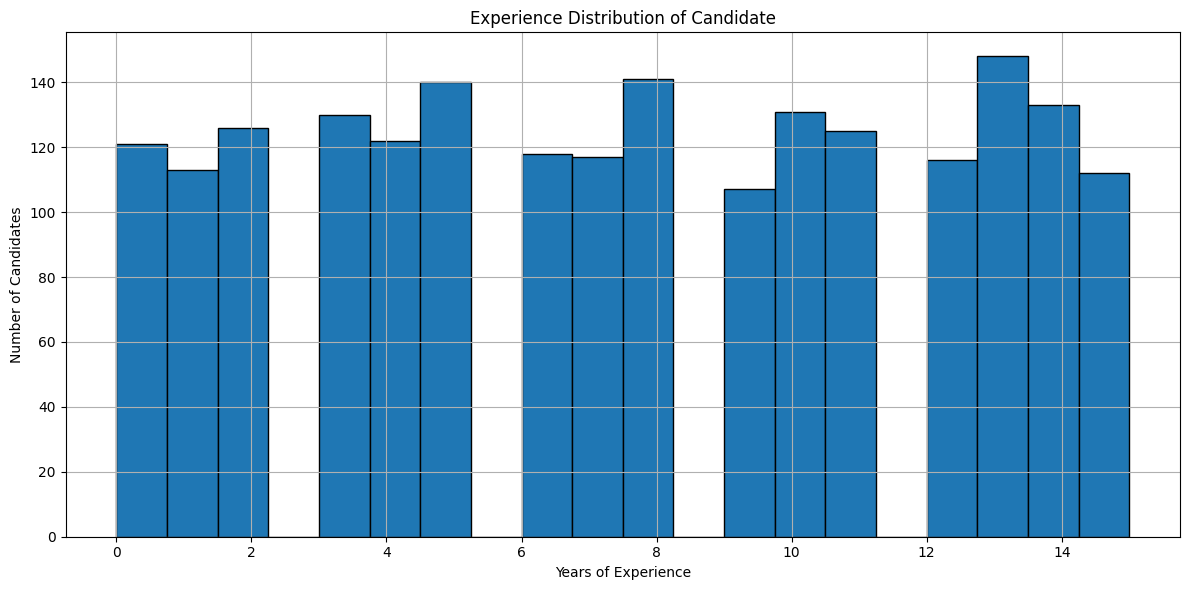

In [25]:
# Create sample visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of experience
plt.figure(figsize=(12, 6))
df["Experience_Years"].hist(bins=20, edgecolor="black")
plt.title("Experience Distribution of Candidate")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Candidates")
plt.tight_layout()
plt.show()
plt.savefig("experiecne_deistribution.png")
plt.close()

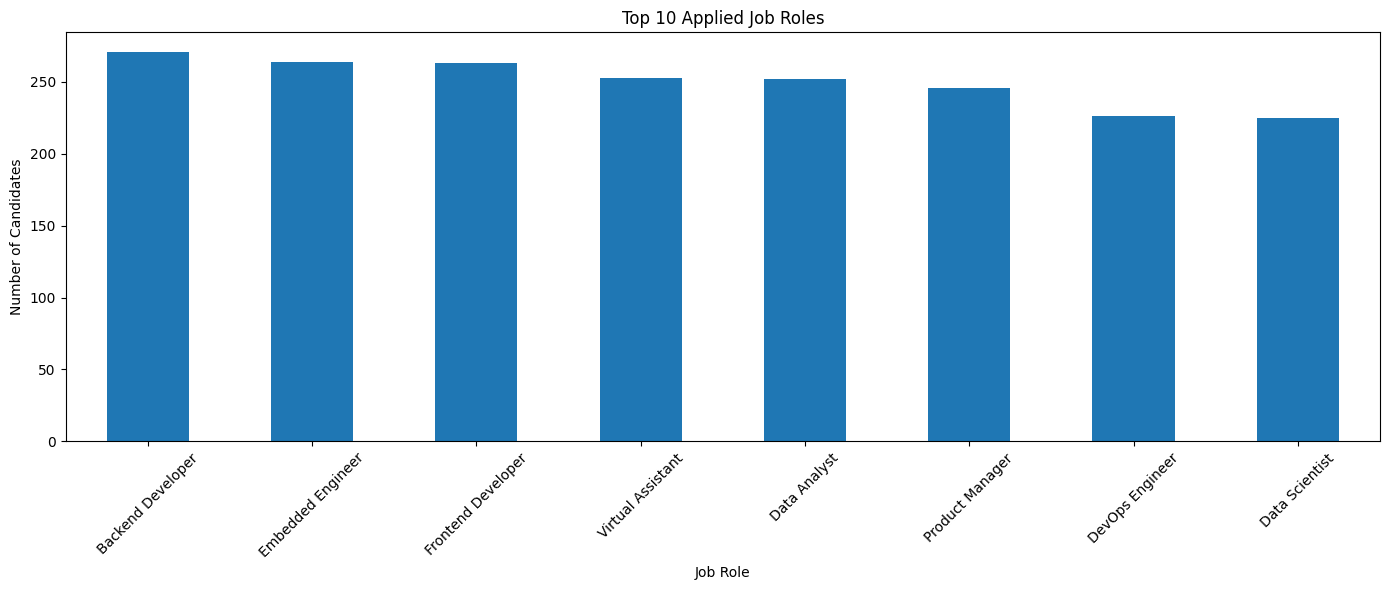

In [26]:
# Ditribution of applied roles
if "Applied_Job_Role" in df.columns:
  plt.figure(figsize=(14, 6))
  df["Applied_Job_Role"].value_counts().head(10).plot(kind="bar")
  plt.title("Top 10 Applied Job Roles")
  plt.xlabel("Job Role")
  plt.ylabel("Number of Candidates")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
  plt.savefig("applied_roles.png")
  plt.close()
else:
  print("No 'Applied_Job_Role' column found in the DataFrame.")

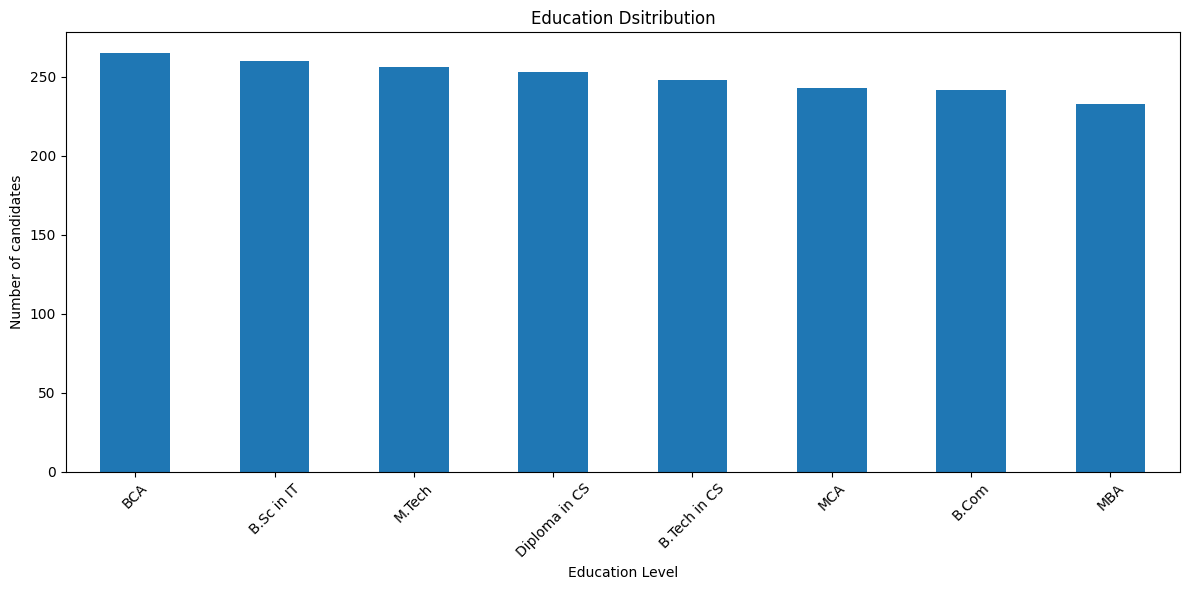

In [27]:
# Education distribution
if "Education" in df.columns:
  plt.figure(figsize=(12, 6))
  df["Education"].value_counts().plot(kind="bar")
  plt.title("Education Dsitribution")
  plt.xlabel("Education Level")
  plt.ylabel("Number of candidates")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
  plt.savefig("education_distribution.png")
  plt.close()
else:
    print("No 'Education' column found in the DataFrame.")